# Préparation de données cliniques — hépatologie

**Chargement des données**

Nous commençons par charger les jeux de données JSON et CSV fournis. Nous utiliserons la bibliothèque `pandas` pour cela.

In [1]:
# ============================================================
# CONFIGURATION
# ============================================================
import sys, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive'
else:
    BASE_DIR = './data'

CSV_PATH = os.path.join(BASE_DIR, 'liver.csv')
JSON_PATH = os.path.join(BASE_DIR, 'liver.json')

print(f"Environnement : {'Google Colab' if IN_COLAB else 'Local'}")

Mounted at /content/drive
Environnement : Google Colab


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE
from scipy import stats

print("-- 1. Chargement et Harmonisation des Données --\n")

df_csv = pd.read_csv(CSV_PATH)
df_json = pd.read_json(JSON_PATH)

print(f"CSV : {df_csv.shape}")
print(f"JSON : {df_json.shape}")

-- 1. Chargement et Harmonisation des Données --

CSV : (321, 11)
JSON : (291, 11)


**Voici un aperçu des données originales pour le fichier .csv**

In [3]:
print(f"La taille du dataset est : {df_csv.shape} \n")
print("Aperçu des 5 premières lignes du CSV : \n")
print(df_csv.head())
print("\nVoici quelques informations sur le CSV : \n")
print(df_csv.info())

La taille du dataset est : (321, 11) 

Aperçu des 5 premières lignes du CSV : 

           Age Gender  Total_Bilirubin  Direct_Bilirubin  \
0  41 to 60 yo   Male              7.0               2.0   
1  41 to 60 yo   Male              6.0               2.0   
2  21 to 40 yo   Male             11.0               5.0   
3  21 to 40 yo   Male             24.0              10.0   
4  21 to 40 yo   Male              6.0               2.0   

   Alkaline_Phosphotase   ALT  AST Total_Proteins  Albumin  \
0                 174.0   NaN   14   7800.0 mg/dL      4.2   
1                 245.0  22.0   24   7100.0 mg/dL      3.4   
2                 191.0  37.0   41   7700.0 mg/dL      4.3   
3                 340.0  25.0   21   8300.0 mg/dL      4.5   
4                 202.0   NaN   41   8000.0 mg/dL      3.9   

   Albumin_and_Globulin_Ratio  Result  
0                         NaN       2  
1                         0.9       1  
2                         NaN       2  
3                         

**Voici un aperçu des données originales pour le fichier .json**


In [4]:
print(f"La taille du dataset est : {df_json.shape} \n")
print("Aperçu des 5 premières lignes du JSON : \n")
print(df_json.head())
print("\nVoici quelques informations sur le JSON : \n")
print(df_json.info())

La taille du dataset est : (291, 11) 

Aperçu des 5 premières lignes du JSON : 

           Age  Gender  Total_Bilirubin  Direct_Bilirubin  \
0  61 to 80 yo  Female              0.7               0.1   
1  61 to 80 yo    Male             10.9               5.5   
2  61 to 80 yo    Male              7.3               4.1   
3  41 to 60 yo    Male              1.0               0.4   
4  61 to 80 yo    Male              3.9               2.0   

   Alkaline_Phosphotase  Alamine_Aminotransferase  Aspartate_Aminotransferase  \
0                 187.0                       NaN                          18   
1                 699.0                      64.0                         100   
2                 490.0                       NaN                          68   
3                 182.0                      14.0                          20   
4                 195.0                      27.0                          59   

   Total_Proteins  Albumin  Albumin_and_Globulin_Ratio  Outcome  

**Contrôle de cohérence des échelles entre les deux sources**

Avant de fusionner, nous vérifions que les deux fichiers expriment chaque variable dans la même unité, en comparant les médianes variable par variable.

In [5]:
# Comparaison des médianes par source, avant fusion.
# Un ratio proche de 1 = même échelle. Un ratio proche de 10 = échelle différente à harmoniser.
# Albumin et Alkaline_Phosphotase servent de témoins.
colonnes_a_comparer = ['Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Albumin']
comparaison = pd.DataFrame({
    'Médiane CSV': df_csv[colonnes_a_comparer].median(),
    'Médiane JSON': df_json[colonnes_a_comparer].median(),
})
comparaison['Ratio CSV/JSON'] = (comparaison['Médiane CSV'] / comparaison['Médiane JSON']).round(2)
print(comparaison)

                      Médiane CSV  Médiane JSON  Ratio CSV/JSON
Total_Bilirubin              10.0           1.1            9.09
Direct_Bilirubin              3.0           0.4            7.50
Alkaline_Phosphotase        204.0         222.0            0.92
Albumin                       3.2           3.0            1.07


**Résultat du contrôle** : le ratio CSV/JSON est d'environ 9 (bilirubine totale) et 7,5 (bilirubine directe), contre environ 1 pour les deux variables témoins (phosphatase alcaline, albumine). Le CSV exprime donc la bilirubine avec un facteur ≈ 10 par rapport au JSON (vraisemblablement mg/L contre mg/dL, à confirmer dans l'énoncé du cours). Nous divisons les valeurs du CSV par 10 avant la fusion.

In [6]:
# Harmonisation d'échelle : la bilirubine du CSV est exprimée ×10 par rapport au JSON
df_csv[['Total_Bilirubin', 'Direct_Bilirubin']] = df_csv[['Total_Bilirubin', 'Direct_Bilirubin']] / 10

**Harmonisation des noms des colonnes des 2 fichiers puis fusion des 2 fichiers**

Les doublons sont supprimés avant tout découpage train/test, pour qu'un même patient ne se retrouve pas des deux côtés.

In [7]:
rename_dict = {
    'ALT': 'Alamine_Aminotransferase',
    'AST': 'Aspartate_Aminotransferase',
    'Result': 'Outcome'
}
df_csv = df_csv.rename(columns=rename_dict)

df = pd.concat([df_csv, df_json], axis=0, ignore_index=True)
df = df.drop_duplicates()

print(f"Taille du dataset fusionné : {df.shape} \n")
print("Aperçu des 5 premières lignes fusionnées : \n")
print(df.head())

Taille du dataset fusionné : (607, 11) 

Aperçu des 5 premières lignes fusionnées : 

           Age Gender  Total_Bilirubin  Direct_Bilirubin  \
0  41 to 60 yo   Male              0.7               0.2   
1  41 to 60 yo   Male              0.6               0.2   
2  21 to 40 yo   Male              1.1               0.5   
3  21 to 40 yo   Male              2.4               1.0   
4  21 to 40 yo   Male              0.6               0.2   

   Alkaline_Phosphotase  Alamine_Aminotransferase  Aspartate_Aminotransferase  \
0                 174.0                       NaN                          14   
1                 245.0                      22.0                          24   
2                 191.0                      37.0                          41   
3                 340.0                      25.0                          21   
4                 202.0                       NaN                          41   

  Total_Proteins  Albumin  Albumin_and_Globulin_Ratio  Outcome  
0

**Visualiser la distribution des données**

Les valeurs 0 biologiquement impossibles sont d'abord remplacées par des valeurs manquantes.

Nombre de valeurs manquantes après remplacement des 0 biologiquement impossibles :

Age                             0
Gender                          0
Total_Bilirubin                 5
Direct_Bilirubin                5
Alkaline_Phosphotase            5
Alamine_Aminotransferase      121
Aspartate_Aminotransferase      0
Total_Proteins                  2
Albumin                         6
Albumin_and_Globulin_Ratio    123
Outcome                         0
dtype: int64


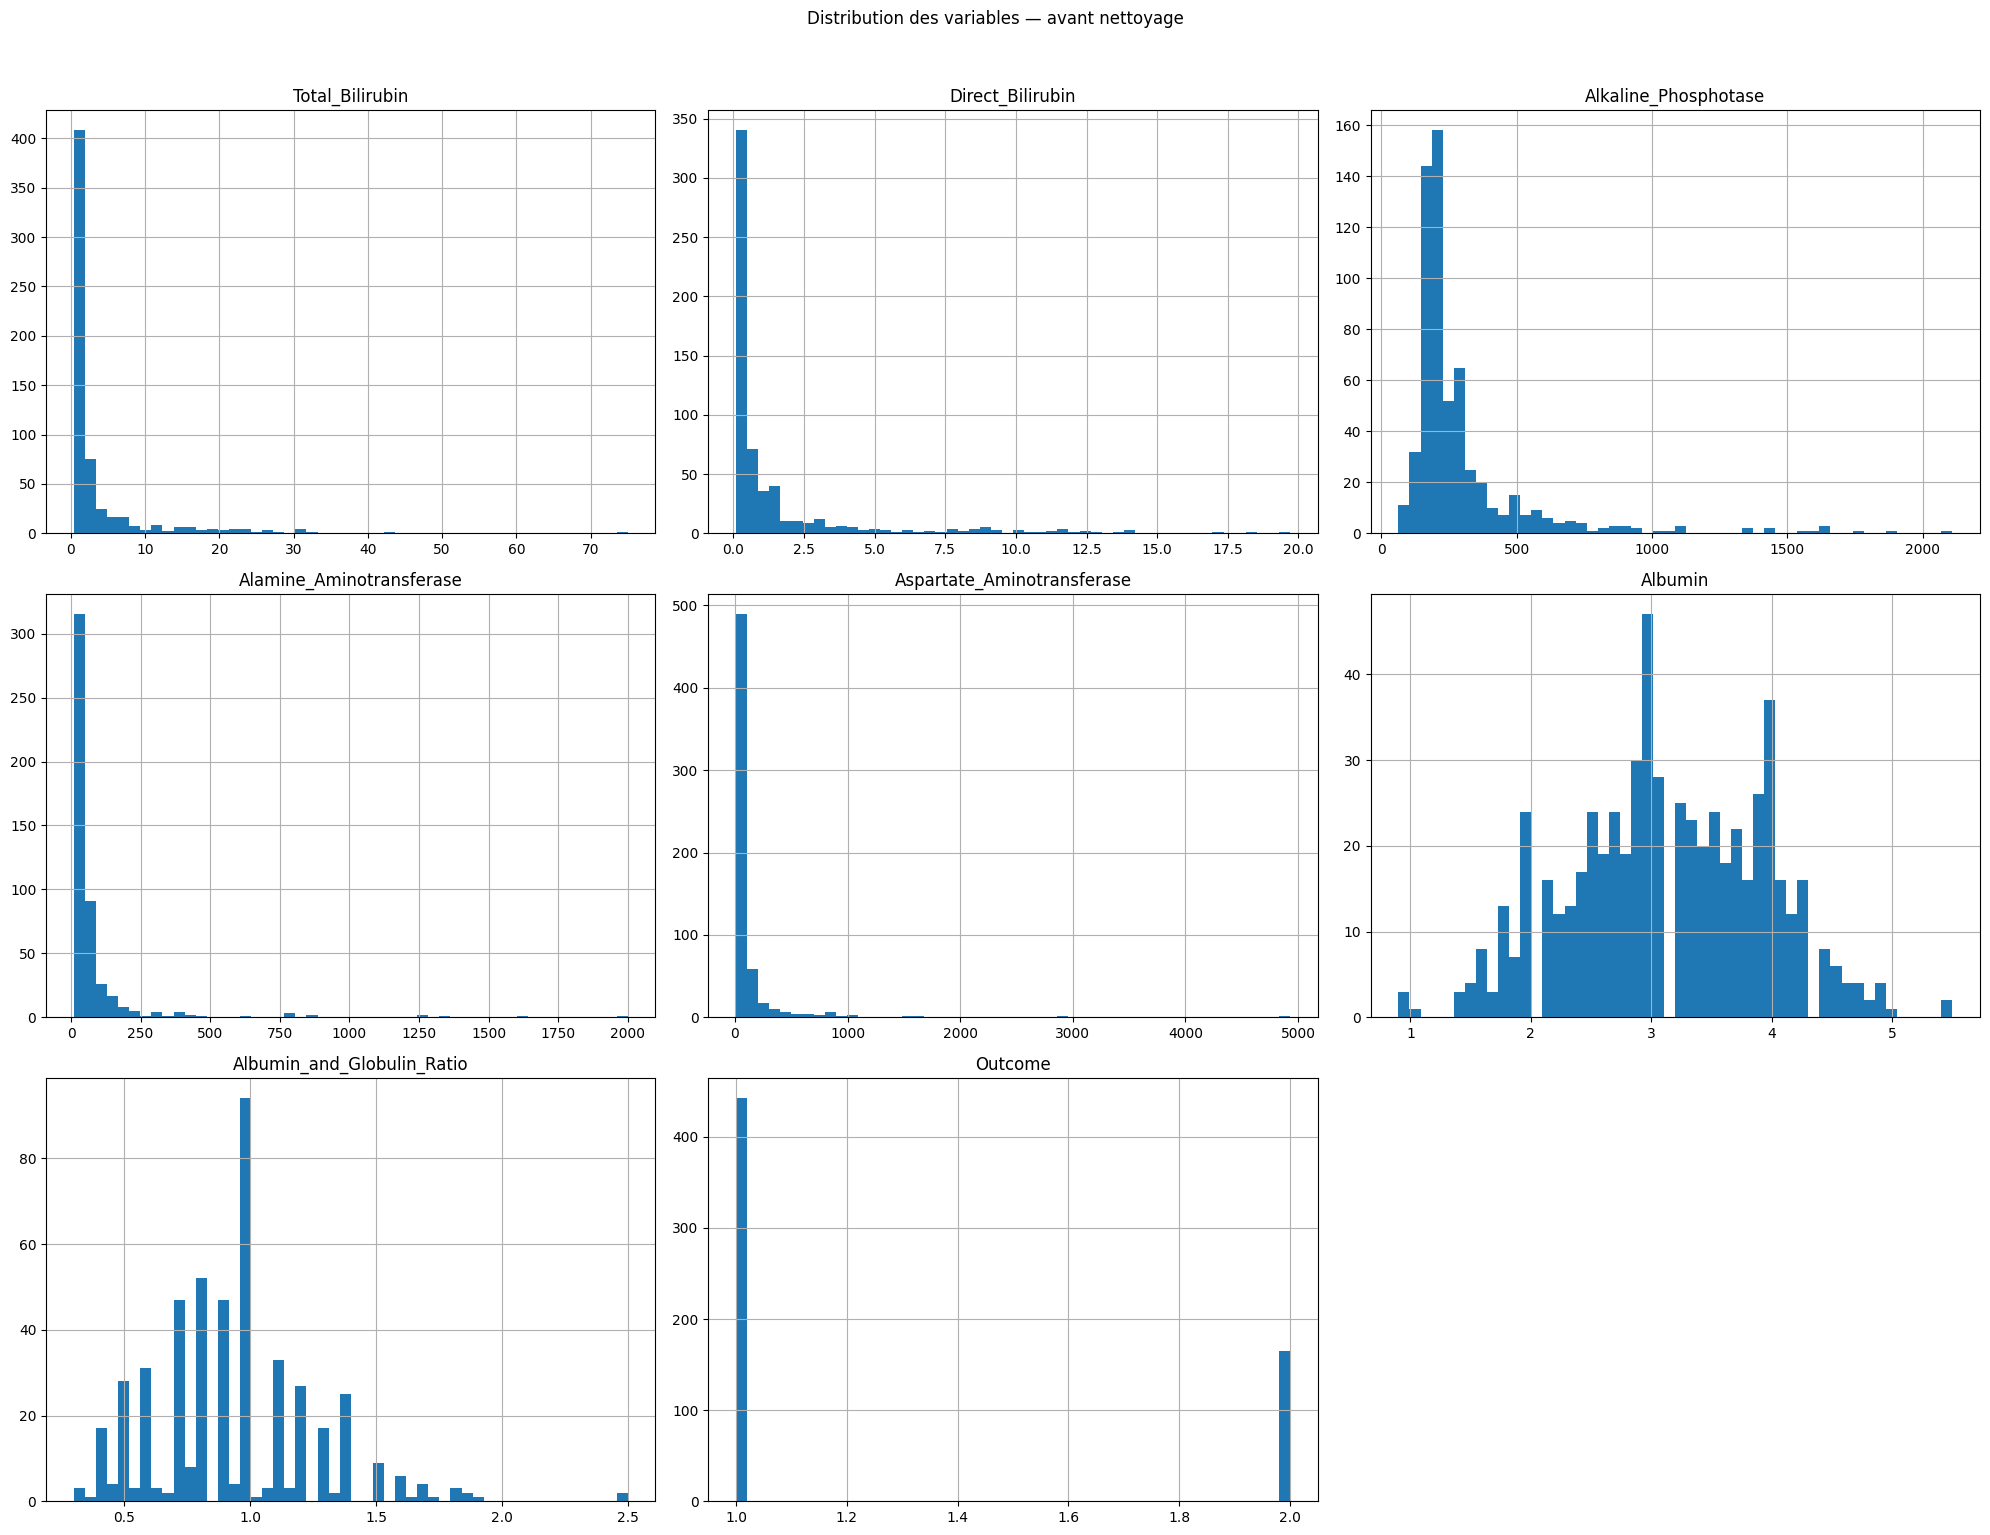

In [8]:
# Remplacement des 0 par NaN UNIQUEMENT sur les colonnes où 0 est biologiquement impossible.
# Age est géré par nettoyer_age ; Gender et Outcome sont des variables catégorielles.
cols_zeros_invalides = [
    'Total_Bilirubin', 'Direct_Bilirubin',
    'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
    'Aspartate_Aminotransferase', 'Total_Proteins',
    'Albumin', 'Albumin_and_Globulin_Ratio'
]
df[cols_zeros_invalides] = df[cols_zeros_invalides].replace(0, np.nan)

print("Nombre de valeurs manquantes après remplacement des 0 biologiquement impossibles :\n")
print(df.isna().sum())

# Age et Total_Proteins sont encore en texte : ils n'apparaissent pas ici
df.hist(bins=50, figsize=(20, 15))
plt.suptitle("Distribution des variables — avant nettoyage", y=1.02)
plt.tight_layout()
plt.show()

**Nous allons maintenant passer au nettoyage et au formatage du dataset**

-- 2. Nettoyage et Formatage -- 

Doublons détectés après harmonisation des formats : 18
Voici les 5 premières lignes du dataset après le nettoyage : 

    Age  Total_Proteins
0  50.5             7.8
1  50.5             7.1
2  30.5             7.7
3  30.5             8.3
4  30.5             8.0


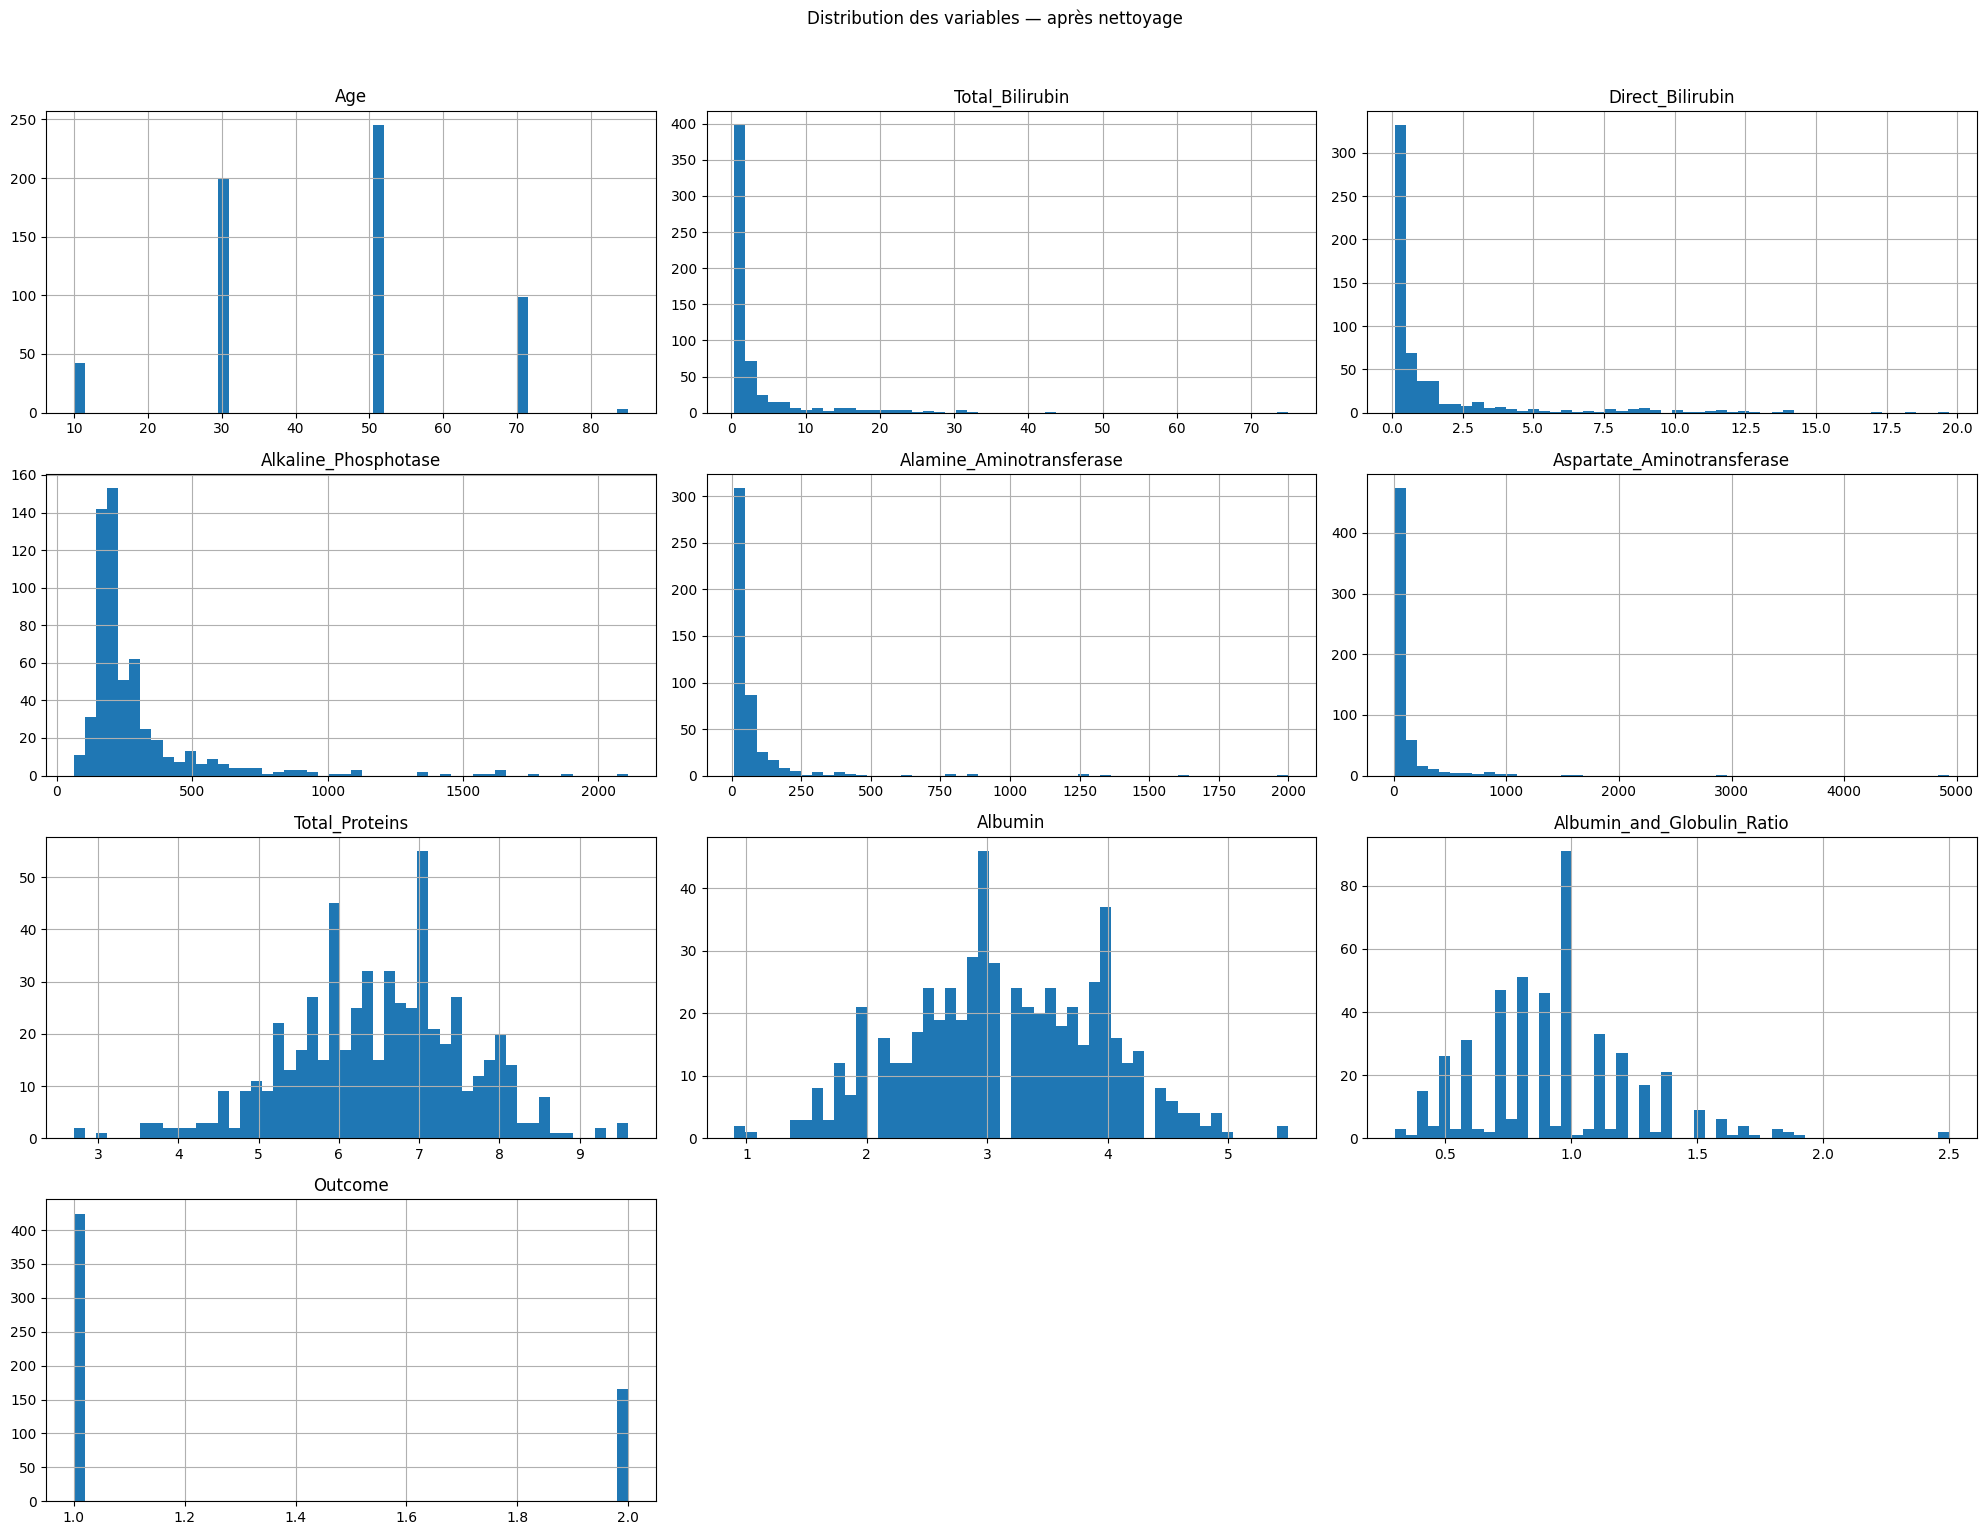

In [9]:
print("-- 2. Nettoyage et Formatage -- \n")

def nettoyer_age(valeur):
    if pd.isna(valeur):
        return np.nan

    texte = str(valeur).lower()
    texte = texte.replace(' yo', '')

    if 'to' in texte:
        parties = texte.split(' to ')
        v1 = float(parties[0])
        v2 = float(parties[1])
        return (v1 + v2) / 2

    elif '<' in texte:
        return 10.0
    elif '>' in texte:
        return 85.0
    else:
        return float(texte)

def nettoyer_proteines(valeur):
    if pd.isna(valeur):
        return np.nan

    texte = str(valeur).lower()

    if 'mg/dl' in texte:
        chiffre = float(texte.replace('mg/dl', ''))
        return chiffre / 1000
    elif 'g/dl' in texte:
        return float(texte.replace('g/dl', ''))
    else:
        return float(valeur)

df['Age'] = df['Age'].apply(nettoyer_age)
df['Total_Proteins'] = df['Total_Proteins'].apply(nettoyer_proteines)

# Doublons éventuels entre les deux sources : détectables seulement maintenant que
# Age, Total_Proteins et la bilirubine sont dans le même format
n_doublons = df.duplicated().sum()
print(f"Doublons détectés après harmonisation des formats : {n_doublons}")
df = df.drop_duplicates()

print("Voici les 5 premières lignes du dataset après le nettoyage : \n")
print(df[['Age', 'Total_Proteins']].head())

df.hist(bins=50, figsize=(20, 15))
plt.suptitle("Distribution des variables — après nettoyage", y=1.02)
plt.tight_layout()
plt.show()

**Nous allons maintenant nous occuper des variables catégorielles**

In [10]:
print("-- 3. Gestion des variables catégorielles --\n")

# Encodage binaire : 1 = Male, 0 = Female
# Une seule colonne suffit pour une variable binaire
df['Gender'] = (df['Gender'] == 'Male').astype(int)

print("Encodage Gender : 1 = Male, 0 = Female")
print(df['Gender'].value_counts())

-- 3. Gestion des variables catégorielles --

Encodage Gender : 1 = Male, 0 = Female
Gender
1    448
0    141
Name: count, dtype: int64


In [11]:
# Une bilirubine et une phosphatase alcaline plus élevées, et une albumine plus basse,
# doivent correspondre à la classe "maladie hépatique".
print(df.groupby('Outcome')[['Total_Bilirubin', 'Alkaline_Phosphotase', 'Albumin']].mean().round(2))

         Total_Bilirubin  Alkaline_Phosphotase  Albumin
Outcome                                                
1                   4.22                 322.7     3.06
2                   1.10                 219.3     3.35


**Ici nous montrerons la première matrice de corrélation, celle que nous avons faite avant les simplifications**

-- 4. Matrice de corrélation (avant simplification) --



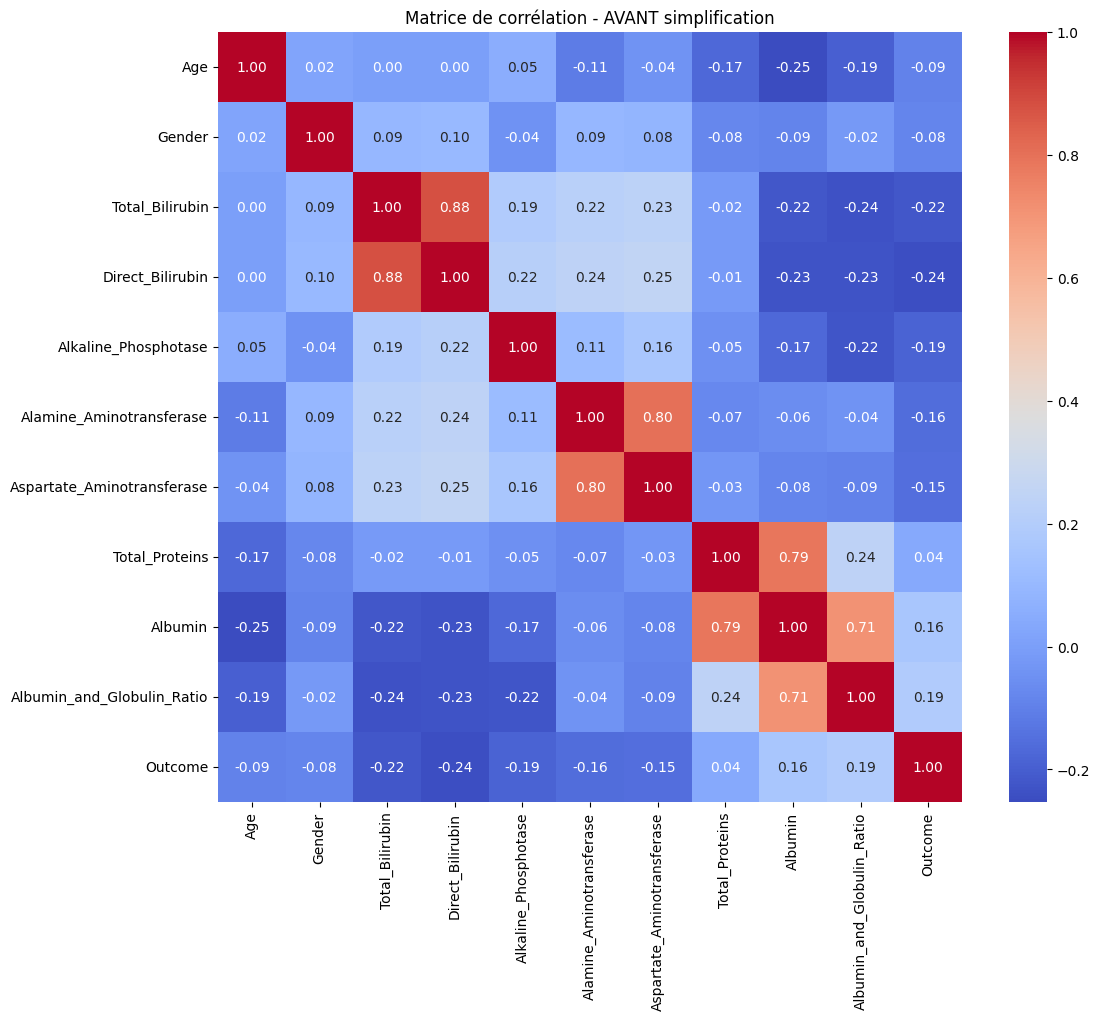

In [12]:
print("-- 4. Matrice de corrélation (avant simplification) --\n")

# pandas ignore les NaN paire par paire : pas besoin d'imputer pour explorer
matrix_corr = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(matrix_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de corrélation - AVANT simplification')
plt.show()

**Nous allons maintenant apporter quelques simplifications au dataset**

Deux variables sont supprimées, pour deux raisons distinctes, sans jamais utiliser la cible :
- `Direct_Bilirubin` : corrélation de 0,88 avec `Total_Bilirubin`, la plus forte du jeu de données.
- `Albumin_and_Globulin_Ratio` : ratio calculé à partir de l'albumine et des protéines totales, donc redondant par construction, et manquant dans 20 % des lignes.

Les paires ALT/AST (0,80) et Protéines totales/Albumine (0,79) sont conservées : ce sont des mesures biologiques distinctes, et le Random Forest utilisé ensuite est peu sensible à la colinéarité.

In [13]:
print("-- 5. Simplification des variables --\n")

# Paires de variables explicatives fortement corrélées (la cible est exclue du calcul)
corr_abs = df.drop(columns='Outcome').corr().abs()
paires = (corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
                  .stack().sort_values(ascending=False))
print("Paires avec |corrélation| > 0.7 :\n")
print(paires[paires > 0.7].round(2))

# Direct_Bilirubin : paire la plus corrélée (0.88) ; Albumin_and_Globulin_Ratio : dérivé d'Albumin et Total_Proteins
cols_a_supprimer = ['Direct_Bilirubin', 'Albumin_and_Globulin_Ratio']
df = df.drop(columns=cols_a_supprimer)

print(f"\nVariables supprimées : {cols_a_supprimer}")
print(f"Il reste {df.shape[1]} colonnes (cible Outcome incluse)")

-- 5. Simplification des variables --

Paires avec |corrélation| > 0.7 :

Total_Bilirubin           Direct_Bilirubin              0.88
Alamine_Aminotransferase  Aspartate_Aminotransferase    0.80
Total_Proteins            Albumin                       0.79
Albumin                   Albumin_and_Globulin_Ratio    0.71
dtype: float64

Variables supprimées : ['Direct_Bilirubin', 'Albumin_and_Globulin_Ratio']
Il reste 9 colonnes (cible Outcome incluse)


**Voici la matrice de corrélation finale, après les simplifications**

-- 6. Matrice de corrélation (après simplification) --



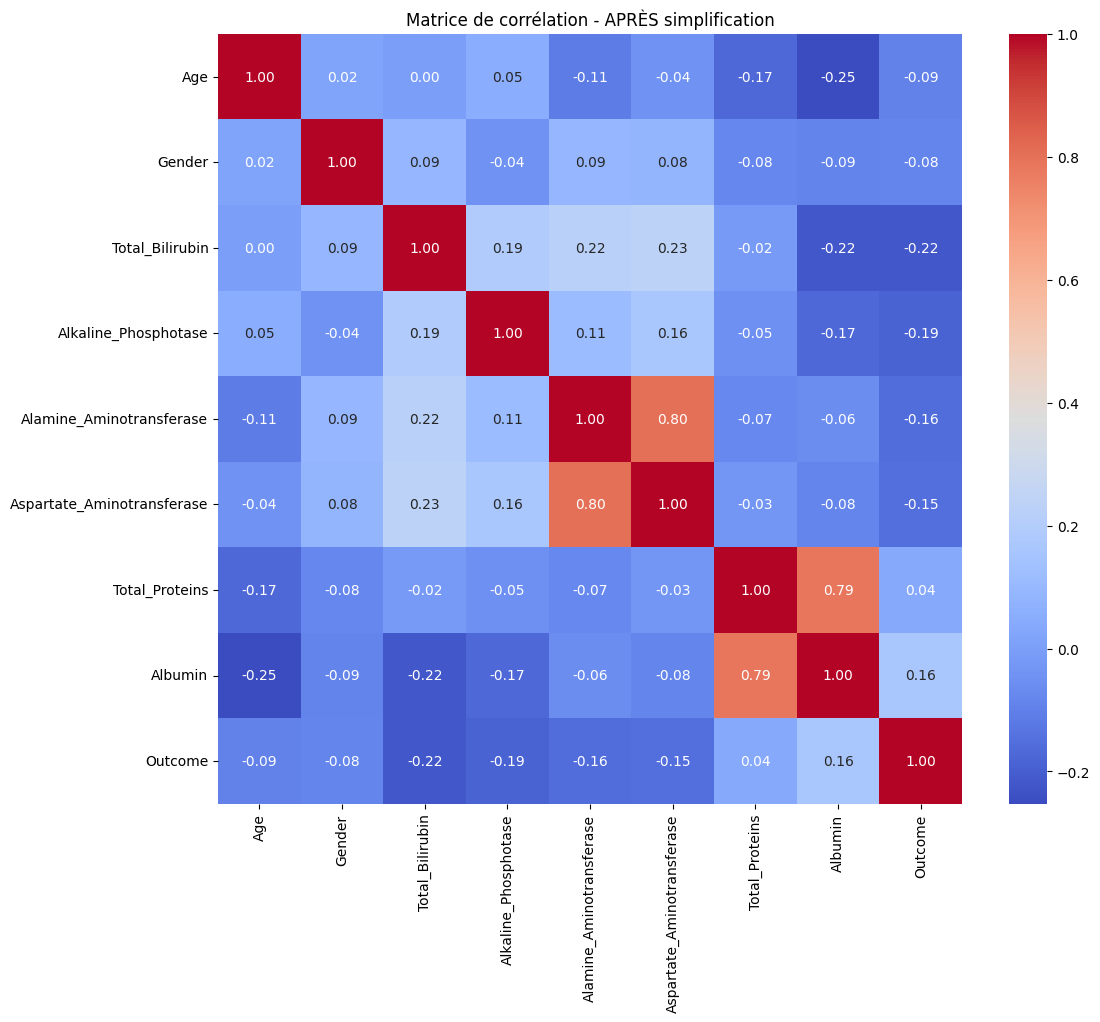

In [14]:
print("-- 6. Matrice de corrélation (après simplification) --\n")
corr_finale = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_finale, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de corrélation - APRÈS simplification')
plt.show()

## Pipeline de préparation — ordre strict

L'ordre est critique pour éviter toute fuite de données :
1. **Split** train/test d'abord
2. **Imputation** KNN : `fit` sur train, `transform` sur les deux
3. **Outliers** : suppression sur train uniquement
4. **Normalisation** : `fit` sur train, `transform` sur les deux
5. **SMOTE** : uniquement sur train
6. **Évaluation** : sur test non touché

In [15]:
print("-- 7. Séparation Train / Test --\n")

# Séparation des features et de la cible
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split stratifié AVANT tout traitement
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train : {X_train.shape} — Test : {X_test.shape}")
print(f"Distribution train :\n{y_train.value_counts()}")
print(f"\nDistribution test :\n{y_test.value_counts()}")

-- 7. Séparation Train / Test --

Train : (471, 8) — Test : (118, 8)
Distribution train :
Outcome
1    339
2    132
Name: count, dtype: int64

Distribution test :
Outcome
1    85
2    33
Name: count, dtype: int64


**Nous allons maintenant nous occuper des valeurs manquantes à l'aide du KNN**

-- 8. Traitement des valeurs manquantes --

Valeurs manquantes par variable :

Total_Bilirubin               5
Alkaline_Phosphotase          5
Alamine_Aminotransferase    115
Total_Proteins                5
Albumin                       5
dtype: int64


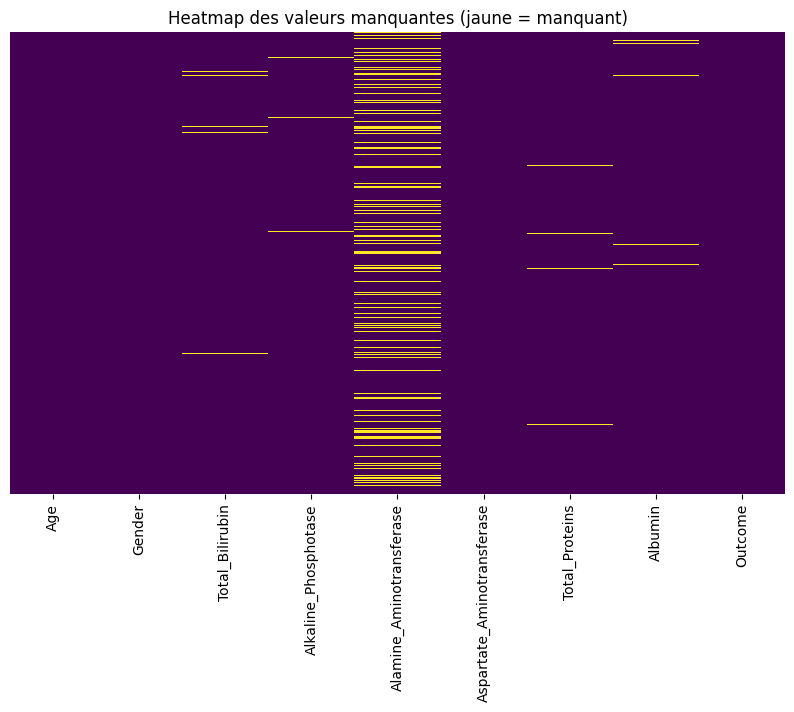


Si on supprime les lignes incomplètes : 589 → 458 lignes
Trop d'information perdue : on impute par KNN (appris sur le train uniquement).


In [16]:
print("-- 8. Traitement des valeurs manquantes --\n")

manquants = df.isna().sum()
print("Valeurs manquantes par variable :\n")
print(manquants[manquants > 0])

plt.figure(figsize=(10, 6))
sns.heatmap(df.isna(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Heatmap des valeurs manquantes (jaune = manquant)")
plt.show()

nb_total, nb_sans_vide = len(df), len(df.dropna())
print(f"\nSi on supprime les lignes incomplètes : {nb_total} → {nb_sans_vide} lignes")
print("Trop d'information perdue : on impute par KNN (appris sur le train uniquement).")

In [17]:
print("-- 8a. Imputation des valeurs manquantes (KNN) --\n")

# fit sur train UNIQUEMENT, transform sur les deux
imputer = KNNImputer(n_neighbors=5)
X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index
)
X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns, index=X_test.index
)

print(f"Valeurs manquantes train après imputation : {X_train_imp.isna().sum().sum()}")
print(f"Valeurs manquantes test après imputation : {X_test_imp.isna().sum().sum()}")

-- 8a. Imputation des valeurs manquantes (KNN) --

Valeurs manquantes train après imputation : 0
Valeurs manquantes test après imputation : 0


**Ici nous allons gérer les outliers**

In [18]:
print("-- 9. Suppression des outliers (train uniquement) --\n")

# On ne supprime les outliers que sur le train
# Le test doit rester représentatif de la distribution réelle
cols_numeriques = X_train_imp.drop(['Gender'], axis=1).columns
z_scores = np.abs(stats.zscore(X_train_imp[cols_numeriques]))
mask_outliers = (z_scores > 3).sum(axis=1) <= 2

X_train_clean = X_train_imp[mask_outliers]
y_train_clean = y_train[mask_outliers]

print(f"Train avant outliers : {X_train_imp.shape[0]}")
print(f"Train après outliers : {X_train_clean.shape[0]}")
print(f"Patients supprimés : {X_train_imp.shape[0] - X_train_clean.shape[0]}")

-- 9. Suppression des outliers (train uniquement) --

Train avant outliers : 471
Train après outliers : 469
Patients supprimés : 2


**Nous allons maintenant nous occuper de la normalisation**

In [19]:
print("-- 10. Normalisation (StandardScaler) --\n")

# fit sur train, transform sur les deux
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_clean),
    columns=X_train_clean.columns, index=X_train_clean.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imp),
    columns=X_test_imp.columns, index=X_test_imp.index
)

print("Statistiques train après normalisation :")
print(X_train_scaled.describe().loc[['mean', 'std']].round(3))

-- 10. Normalisation (StandardScaler) --

Statistiques train après normalisation :
        Age  Gender  Total_Bilirubin  Alkaline_Phosphotase  \
mean -0.000   0.000           -0.000                 0.000   
std   1.001   1.001            1.001                 1.001   

      Alamine_Aminotransferase  Aspartate_Aminotransferase  Total_Proteins  \
mean                    -0.000                      -0.000          -0.000   
std                      1.001                       1.001           1.001   

      Albumin  
mean    0.000  
std     1.001  


**Nous allons nous occuper de la gestion du déséquilibre de classe**

In [20]:
print("-- 11. Rééquilibrage par SMOTE (train uniquement) --\n")

print(f"Distribution AVANT SMOTE :\n{y_train_clean.value_counts()}\n")

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train_clean)

print(f"Distribution APRÈS SMOTE :\n{y_train_bal.value_counts()}")
print(f"\nLe test ({X_test_scaled.shape[0]} exemples) n'a PAS été touché par SMOTE")

-- 11. Rééquilibrage par SMOTE (train uniquement) --

Distribution AVANT SMOTE :
Outcome
1    337
2    132
Name: count, dtype: int64

Distribution APRÈS SMOTE :
Outcome
1    337
2    337
Name: count, dtype: int64

Le test (118 exemples) n'a PAS été touché par SMOTE


## Classification supervisée

Entraînement d'un Random Forest sur les données préparées, évaluation sur le test non touché.

La variable cible `Outcome` vaut 1 ou 2 (1 = maladie hépatique, 2 = pas de maladie — vérifié ci-dessus : bilirubine et phosphatase alcaline plus élevées en classe 1). Pour un dépistage, le **rappel sur la classe « maladie »** importe davantage que l'accuracy globale : un patient malade non détecté est plus grave qu'une fausse alerte.

In [21]:
print("-- 12. Classification (Random Forest) --\n")

# Les classes sont déjà équilibrées par SMOTE : pas de class_weight
clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
clf.fit(X_train_bal, y_train_bal)

y_pred = clf.predict(X_test_scaled)

print("Rapport de classification (test) :\n")
print(classification_report(y_test, y_pred, digits=3))
print(f"\nF1 macro : {f1_score(y_test, y_pred, average='macro'):.4f}")

-- 12. Classification (Random Forest) --

Rapport de classification (test) :

              precision    recall  f1-score   support

           1      0.836     0.718     0.772        85
           2      0.467     0.636     0.538        33

    accuracy                          0.695       118
   macro avg      0.651     0.677     0.655       118
weighted avg      0.732     0.695     0.707       118


F1 macro : 0.6553


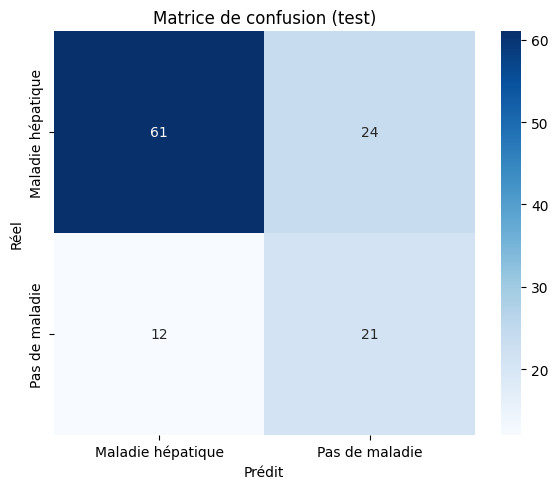

In [22]:
# Sens validé par la cellule de contrôle de Outcome (bilirubine et phosphatase plus élevées en classe 1)
OUTCOME_LABELS = {1: 'Maladie hépatique', 2: 'Pas de maladie'}
classes = sorted(y_test.unique())
noms = [OUTCOME_LABELS[c] for c in classes]

cm = confusion_matrix(y_test, y_pred, labels=classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=noms, yticklabels=noms)
plt.title('Matrice de confusion (test)')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.show()

## Validation croisée

Le jeu de test ne contient que 118 patients, dont 33 sans maladie : un score calculé dessus est instable. Nous complétons par une validation croisée à 5 plis, où imputation, normalisation et SMOTE sont réappris dans chaque pli. La suppression des outliers n'y figure pas (elle ne s'exprime pas comme étape de pipeline).

In [23]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

# Imputation → scaling → SMOTE → modèle, ré-appris dans chaque fold : aucune fuite possible.
# (La suppression d'outliers n'est pas incluse : elle ne s'exprime pas comme étape de pipeline.)
X_all, y_all = df.drop(columns='Outcome'), df['Outcome']

pipe_cv = ImbPipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(pipe_cv, X_all, y_all, cv=cv, scoring=['f1_macro', 'recall_macro'])

print(f"F1 macro (5-fold)     : {scores['test_f1_macro'].mean():.3f} ± {scores['test_f1_macro'].std():.3f}")
print(f"Rappel macro (5-fold) : {scores['test_recall_macro'].mean():.3f} ± {scores['test_recall_macro'].std():.3f}")

F1 macro (5-fold)     : 0.621 ± 0.068
Rappel macro (5-fold) : 0.627 ± 0.070


## Conclusion

Ce notebook constitue la phase de préparation des données pour un problème de classification binaire en hépatologie.

**Points méthodologiques**
- **Ordre strict du pipeline** : split → imputation → outliers → normalisation → SMOTE, pour éviter toute fuite entre train et test.
- **Harmonisation des deux sources** : bilirubine du CSV ramenée à l'échelle du JSON, protéines converties en g/dL, puis suppression de 18 doublons supplémentaires, détectables seulement après cette harmonisation (589 patients au final).
- **Imputation KNN** plutôt que suppression des lignes incomplètes (perte de 131 lignes sur 589, soit 22 %).
- **SMOTE uniquement sur le train** : le test conserve la distribution réelle.
- **Métrique adaptée** : rappel sur la classe « maladie ».

**Résultats** (test de 118 patients : 85 avec maladie, 33 sans) : F1 macro de 0,655 ; rappel sur la classe « maladie » de 0,718 (61 patients malades détectés sur 85, 24 manqués) ; rappel sur la classe « pas de maladie » de 0,636 (21 sur 33).

**Limites**
- Petit jeu de données (589 patients) : le test ne contient que 118 patients. La validation croisée à 5 plis donne un F1 macro de 0,621 ± 0,068 : l'écart-type est élevé, l'estimation reste instable. Le score sur le test est cohérent avec la validation croisée, mais légèrement plus favorable.
- Environ 3 patients malades sur 10 ne sont pas détectés sur le test (24 sur 85) : le modèle n'est pas utilisable en l'état pour un dépistage.
- L'âge n'est connu que par tranche et a été remplacé par le milieu de la tranche, ce qui fait perdre de la précision.
- Le facteur 10 entre les deux sources pour la bilirubine est déduit des médianes, pas d'une documentation.
- Ce notebook valide surtout la méthode de préparation, pas un modèle prêt pour un usage clinique.